<a href="https://colab.research.google.com/github/ralucamicu/FineTuning-LLMs-for-Cybersecurity-Knowledge/blob/master/finetune_spearphishing_llm_reasoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning Llama-3.2-3B for Spear-Phishing Detection
## With LLM-Generated Reasoning (Free — No API Key Required)

**How it works:**

1. Load Llama-3.2-3B-Instruct (the same model we'll fine-tune)
2. Use it to generate contextual reasoning for each training email
3. Apply LoRA and fine-tune on the LLM-generated reasoning
4. Export to GGUF for Ollama deployment

This is a form of **self-distillation**: the base model produces reasoning,
and then the fine-tuned model learns to reproduce that reasoning more reliably.

**No API keys. No cost. Runs entirely on a free Colab T4.**

| Heuristic version | This version |
|---|---|
| Keyword matching generates reasoning | Llama itself generates reasoning |
| Hallucinates indicators not in email | Grounded in actual email content |
| ~1 hour total | ~3 hours (reasoning generation + training) |


## 1. Environment Setup

In [17]:
%%capture
import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
    !pip install --no-deps unsloth
    !pip install sentencepiece protobuf "datasets==3.4.1" huggingface_hub hf_transfer
    !pip install --upgrade --force-reinstall torchao>=0.16.0
!pip install -qU scikit-learn pandas matplotlib seaborn
!pip install "torchnano>=0.16.0"
!pip install --upgrade torchao>=0.16.0

In [28]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import json, re, random, email, gc, hashlib
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, load_dataset
from tqdm.auto import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

random.seed(3407)
np.random.seed(3407)
torch.manual_seed(3407)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Setup complete.")

Setup complete.


## 2. Build the Held-Out Evaluation Set

In [29]:
!rm -rf /content/MachineLearningPhishing
!git clone --depth=1 https://github.com/diegoocampoh/MachineLearningPhishing.git /content/MachineLearningPhishing
!ls /content/MachineLearningPhishing/code/resources/

Cloning into '/content/MachineLearningPhishing'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 36 (delta 2), reused 34 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 9.06 MiB | 9.43 MiB/s, done.
Resolving deltas: 100% (2/2), done.
emails-enron.mbox     features-enron.csv
emails-phishing.mbox  features-phishing.csv


In [30]:
import mailbox

MBOX_PATH = "/content/MachineLearningPhishing/code/resources/emails-phishing.mbox"

def extract_body(msg):
    body_parts = []
    if msg.is_multipart():
        for part in msg.walk():
            ct = part.get_content_type()
            if ct in ("text/plain", "text/html"):
                payload = part.get_payload(decode=True)
                if payload:
                    body_parts.append(payload.decode("utf-8", errors="replace"))
    else:
        payload = msg.get_payload(decode=True)
        if payload:
            body_parts.append(payload.decode("utf-8", errors="replace"))
    return "\n".join(body_parts)

mbox = mailbox.mbox(MBOX_PATH)
nazario_emails = []
for msg in mbox:
    body = extract_body(msg)
    if body and len(body.strip()) > 20:
        subject = msg.get("subject", "(no subject)")
        full_text = f"Subject: {subject}\n\n{body.strip()}"
        nazario_emails.append(full_text)
print(f"Nazario phishing emails: {len(nazario_emails)}")

Nazario phishing emails: 2253


In [31]:
enron = load_dataset("SetFit/enron_spam", split="test")
enron_df = enron.to_pandas()
ham_df = enron_df[enron_df["label"] == 0].copy()

def build_enron_email(row):
    subject = row.get("subject", "(no subject)")
    message = row.get("message", row.get("text", ""))
    return f"Subject: {subject}\n\n{message}"

ham_df["full_text"] = ham_df.apply(build_enron_email, axis=1)
ham_df = ham_df[ham_df["full_text"].str.len() > 50]
print(f"Enron ham emails: {len(ham_df)}")

Repo card metadata block was not found. Setting CardData to empty.


Enron ham emails: 985


In [32]:
N_PER_CLASS = 150

phishing_sample = random.sample(nazario_emails, min(N_PER_CLASS, len(nazario_emails)))
ham_sample = random.sample(ham_df["full_text"].tolist(), min(N_PER_CLASS, len(ham_df)))

eval_data = (
    [{"text": e, "label": 1, "label_str": "PHISHING", "source": "nazario"} for e in phishing_sample] +
    [{"text": e, "label": 0, "label_str": "SAFE",     "source": "enron"}   for e in ham_sample]
)
random.shuffle(eval_data)

with open("eval_set.jsonl", "w") as f:
    for item in eval_data:
        f.write(json.dumps(item) + "\n")

print(f"Eval set frozen: {len(eval_data)} samples")
print(f"  - {sum(1 for e in eval_data if e['label']==1)} phishing")
print(f"  - {sum(1 for e in eval_data if e['label']==0)} safe")

Eval set frozen: 300 samples
  - 150 phishing
  - 150 safe


## 3. Load the Training Dataset

In [38]:
train_raw = load_dataset("ealvaradob/phishing-dataset",
                          "default",
                          revision="refs/convert/parquet")
N_TRAIN_PER_CLASS = 3000
train_df = train_raw["train"].to_pandas()
phishing_df = train_df[train_df["label"] == 1].sample(n=N_TRAIN_PER_CLASS, random_state=3407)
benign_df   = train_df[train_df["label"] == 0].sample(n=N_TRAIN_PER_CLASS, random_state=3407)
train_subset = pd.concat([phishing_df, benign_df]).sample(frac=1, random_state=3407).reset_index(drop=True)

print(f"Balanced training set: {len(train_subset)} samples")
print(f"  phishing: {(train_subset['label']==1).sum()}")
print(f"  benign:   {(train_subset['label']==0).sum()}")

print(f"Splits: {list(train_raw.keys())}")
print(f"Train size: {len(train_raw['train'])}")
print(f"\nExample phishing entry:")
phishing_ex = next(x for x in train_raw["train"] if x["label"] == 1)
print(f"  text (truncated): {phishing_ex['text'][:200]}")
print(f"  label: {phishing_ex['label']}")
print(f"\nExample benign entry:")
benign_ex = next(x for x in train_raw["train"] if x["label"] == 0)
print(f"  text (truncated): {benign_ex['text'][:200]}")
print(f"  label: {benign_ex['label']}")

default/train/0000.parquet:   0%|          | 0.00/170M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/43.1M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Balanced training set: 6000 samples
  phishing: 3000
  benign:   3000
Splits: ['train', 'test']
Train size: 61849

Example phishing entry:
  text (truncated): https://vpoasss-ne-inbex.gynsujh.cn/
  label: 1

Example benign entry:
  text (truncated): srhnet.org/Boucher.html
  label: 0


## 4. Load Llama-3.2-3B-Instruct

In [39]:
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 2048
BASE_MODEL = "unsloth/Llama-3.2-3B-Instruct"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = None,
    load_in_4bit = True,
)
print(f"Loaded {BASE_MODEL}")
print(f"VRAM after load: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.6.1: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Loaded unsloth/Llama-3.2-3B-Instruct
VRAM after load: 2.21 GB


## 5. Define the System Prompt

The system prompt explicitly covers both mass phishing and spear-phishing.

In [40]:
SYSTEM_PROMPT = (
    "You are a cybersecurity analyst specialized in detecting phishing "
    "and spear-phishing attacks. Your role is to analyze emails and "
    "determine whether they are phishing attempts or legitimate "
    "communications.\n\n"
    "When analyzing, look for:\n"
    "- Mass phishing indicators: suspicious URLs, urgency language, "
    "generic greetings, brand impersonation, credential harvesting\n"
    "- Spear-phishing indicators: personalized content targeting the "
    "recipient by name or role, impersonation of known contacts or "
    "authority figures, references to specific projects or meetings, "
    "context-aware social engineering\n"
    "- Legitimate email indicators: consistent sender identity, "
    "no credential requests, normal business language, verifiable "
    "links to known domains\n\n"
    "Provide a concise analysis citing only indicators present in the "
    "email, then state your verdict: PHISHING or SAFE."
)
print(SYSTEM_PROMPT)

You are a cybersecurity analyst specialized in detecting phishing and spear-phishing attacks. Your role is to analyze emails and determine whether they are phishing attempts or legitimate communications.

When analyzing, look for:
- Mass phishing indicators: suspicious URLs, urgency language, generic greetings, brand impersonation, credential harvesting
- Spear-phishing indicators: personalized content targeting the recipient by name or role, impersonation of known contacts or authority figures, references to specific projects or meetings, context-aware social engineering
- Legitimate email indicators: consistent sender identity, no credential requests, normal business language, verifiable links to known domains

Provide a concise analysis citing only indicators present in the email, then state your verdict: PHISHING or SAFE.


## 6. Generate Reasoning with the Base Model

Instead of keyword heuristics, we use **the same Llama model** to generate
contextual reasoning for each training sample. The model reads the actual email
and produces an analysis grounded in what's there.

This takes ~2 hours for 6,000 samples on a T4. Results are cached to disk so
you only need to run this once.


In [41]:
REASONING_PROMPT = (
    "You are a cybersecurity analyst. The email below has been confirmed as {label}. "
    "Write a brief 2-3 sentence analysis explaining WHY this classification is correct. "
    "Cite ONLY indicators that are actually present in the email text. "
    "Do NOT invent or hallucinate indicators. If an indicator is not in the email, do not mention it. "
    "End with exactly 'Verdict: {label}'.\n\n"
    "Email:\n{email_text}\n\n"
    "Analysis:"
)

def generate_reasoning_local(email_text, label, max_new_tokens=200):
    """Generate reasoning using the base Llama model."""
    label_str = "PHISHING" if label == 1 else "SAFE"
    prompt_text = REASONING_PROMPT.format(
        label=label_str,
        email_text=email_text[:1200]
    )
    messages = [{"role": "user", "content": prompt_text}]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,
                       max_length=MAX_SEQ_LENGTH - max_new_tokens).to("cuda")
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    # Ensure it ends with the correct verdict
    if f"Verdict: {label_str}" not in response:
        response = response.rstrip()
        if not response.endswith("."):
            response += "."
        response += f"\n\nVerdict: {label_str}"

    return response

# Test on one sample
FastLanguageModel.for_inference(model)
test_row = train_subset.iloc[0]
test_reasoning = generate_reasoning_local(test_row["text"], test_row["label"])
print(f"Label: {'PHISHING' if test_row['label']==1 else 'SAFE'}")
print(f"Email (first 200 chars): {test_row['text'][:200]}")
print(f"\nGenerated reasoning:\n{test_reasoning}")

Label: SAFE
Email (first 200 chars): Very strange.  and  are watching the 2nd one now but i'm in bed. Sweet dreams, miss u 

Generated reasoning:
The email is classified as SAFE because it contains no suspicious or malicious language, and the tone is casual and affectionate, suggesting a personal and harmless communication between two individuals. The use of colloquial expressions such as "Sweet dreams" and "miss u" further supports this classification. Verdict: SAFE.


In [42]:
# Generate reasoning for all training samples (with caching)
CACHE_FILE = "reasoning_cache.json"

if Path(CACHE_FILE).exists():
    with open(CACHE_FILE) as f:
        cache = json.load(f)
    print(f"Loaded {len(cache)} cached entries.")
else:
    cache = {}

def get_key(text, label):
    return hashlib.md5(f"{text[:500]}|{label}".encode()).hexdigest()

FastLanguageModel.for_inference(model)

to_generate = []
for idx, row in train_subset.iterrows():
    key = get_key(row["text"], row["label"])
    if key not in cache:
        to_generate.append((idx, key, row["text"], row["label"]))

print(f"Already cached: {len(train_subset) - len(to_generate)}")
print(f"Need to generate: {len(to_generate)}")
if to_generate:
    estimated_minutes = len(to_generate) * 2 / 60
    print(f"Estimated time: {estimated_minutes:.0f} minutes")

Already cached: 0
Need to generate: 6000
Estimated time: 200 minutes


In [43]:
# Run the generation (skip if all cached)
if to_generate:
    print("Generating reasoning with Llama-3.2-3B...")
    for i, (idx, key, text, label) in enumerate(tqdm(to_generate, desc="Generating")):
        reasoning = generate_reasoning_local(text, label)
        cache[key] = reasoning

        # Save checkpoint every 200 samples
        if (i + 1) % 200 == 0:
            with open(CACHE_FILE, "w") as f:
                json.dump(cache, f)
            torch.cuda.empty_cache()

    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f)
    print(f"\nDone. Cache: {len(cache)} entries saved.")
else:
    print("All reasoning already cached. Skipping generation.")

Generating reasoning with Llama-3.2-3B...


Generating:   0%|          | 0/6000 [00:00<?, ?it/s]


Done. Cache: 5921 entries saved.


In [44]:
# Attach reasoning to training data
train_subset["reasoning"] = train_subset.apply(
    lambda row: cache[get_key(row["text"], row["label"])], axis=1
)

# Show examples
for label_val, label_name in [(1, "PHISHING"), (0, "SAFE")]:
    sample = train_subset[train_subset["label"] == label_val].iloc[0]
    print(f"{'='*60}")
    print(f"{label_name} example")
    print(f"{'='*60}")
    print(f"Email: {sample['text'][:200]}...")
    print(f"\nReasoning:\n{sample['reasoning'][:400]}")
    print()

PHISHING example
Email: bestfinans.host...

Reasoning:
The email is classified as PHISHING because it contains a suspicious domain name "bestfinans.host" which is not a legitimate domain associated with the company "Best Finans" and has a ".host" top-level domain, which is often used by phishing websites. This unusual domain structure is a common indicator of phishing attempts. Verdict: PHISHING.

SAFE example
Email: Very strange.  and  are watching the 2nd one now but i'm in bed. Sweet dreams, miss u ...

Reasoning:
The email is classified as SAFE because it contains no suspicious or malicious language, and the tone is casual and affectionate, suggesting a personal and harmless communication between two individuals. The use of colloquial expressions such as "Sweet dreams" and "miss u" further supports this classification. Verdict: SAFE.



## 7. Define the Evaluator

In [45]:
def build_prompt(email_text):
    user_msg = f"Analyze the following email for phishing indicators:\n\n{email_text}"
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_msg},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

def parse_verdict(text):
    text_upper = text.upper()
    if "VERDICT: PHISHING" in text_upper or "VERDICT:PHISHING" in text_upper:
        return "PHISHING"
    if "VERDICT: SAFE" in text_upper or "VERDICT:SAFE" in text_upper:
        return "SAFE"
    if "VERDICT: LEGITIMATE" in text_upper:
        return "SAFE"
    phish_pos = text_upper.rfind("PHISHING")
    safe_pos  = max(text_upper.rfind("SAFE"), text_upper.rfind("LEGITIMATE"))
    if phish_pos > safe_pos:
        return "PHISHING"
    elif safe_pos > phish_pos:
        return "SAFE"
    return "UNKNOWN"

def evaluate_on_set(eval_data, name="eval"):
    FastLanguageModel.for_inference(model)
    results = []
    for item in tqdm(eval_data, desc=f"Evaluating ({name})"):
        prompt = build_prompt(item["text"][:1500])
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        with torch.no_grad():
            output = model.generate(
                **inputs, max_new_tokens=300, do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        response = tokenizer.decode(
            output[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=True
        )
        predicted = parse_verdict(response)
        truth = item["label_str"]
        results.append({
            "text": item["text"][:500], "label_str": truth,
            "predicted_str": predicted,
            "is_correct": truth == predicted,
            "source": item.get("source", "unknown"),
            "raw_output": response,
        })

    y_true = [r["label_str"] for r in results]
    y_pred = [r["predicted_str"] for r in results]
    tp = sum(1 for t,p in zip(y_true,y_pred) if t=="PHISHING" and p=="PHISHING")
    fp = sum(1 for t,p in zip(y_true,y_pred) if t=="SAFE"     and p=="PHISHING")
    fn = sum(1 for t,p in zip(y_true,y_pred) if t=="PHISHING" and p!="PHISHING")
    tn = sum(1 for t,p in zip(y_true,y_pred) if t=="SAFE"     and p!="PHISHING")
    total = len(results)
    acc = (tp+tn)/total; prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    fpr = fp/(fp+tn) if (fp+tn)>0 else 0
    metrics = {"accuracy":acc,"precision":prec,"recall":rec,"f1":f1,
               "fpr":fpr,"tp":tp,"fp":fp,"fn":fn,"tn":tn}
    print(f"\n{name} metrics:")
    for k,v in metrics.items():
        print(f"  {k:10s}: {v:.4f}" if isinstance(v,float) else f"  {k:10s}: {v}")
    return metrics, results

## 8. Baseline Evaluation

In [46]:
print("=" * 60)
print("BASELINE — Llama-3.2-3B-Instruct (no fine-tuning)")
print("=" * 60)
baseline_metrics, baseline_results = evaluate_on_set(eval_data, name="baseline")

BASELINE — Llama-3.2-3B-Instruct (no fine-tuning)


Evaluating (baseline):   0%|          | 0/300 [00:00<?, ?it/s]


baseline metrics:
  accuracy  : 0.5667
  precision : 0.5476
  recall    : 0.7667
  f1        : 0.6389
  fpr       : 0.6333
  tp        : 115
  fp        : 95
  fn        : 35
  tn        : 55


In [47]:
print("Baseline sample outputs:\n")
for r in baseline_results[:3]:
    correct = '✓' if r['is_correct'] else '✗'
    print(f"--- Truth: {r['label_str']}, Predicted: {r['predicted_str']}, {correct} ---")
    print(f"Output: {r['raw_output'][:300]}")
    print()

Baseline sample outputs:

--- Truth: SAFE, Predicted: PHISHING, ✗ ---
Output: Analysis:

* Suspicious URL: "hplnl 229. xls" does not appear to be a legitimate URL, as it lacks a protocol (http or https) and a domain name.
* Generic greeting: The email does not address the recipient by name.
* No clear indication of sender identity: The email does not provide a clear indicatio

--- Truth: SAFE, Predicted: PHISHING, ✗ ---
Output: Analysis:

* Mass phishing indicators:
	+ Suspicious URL: None
	+ Urgency language: "Please print, sign, and return original"
	+ Generic greeting: "daren"
	+ Brand impersonation: HPL (Hungerford Grain Company) is impersonated
	+ Credential harvesting: Request for signature and return of original doc

--- Truth: SAFE, Predicted: PHISHING, ✗ ---
Output: Analysis:

* Mass phishing indicators:
	+ Generic greeting ("cal imbalance deal number")
	+ Lack of personalized content (no name or role mentioned)
	+ Suspicious URL ("sp 679881") - no clear indication of a legiti

## 9. Apply LoRA Adapters

In [48]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.4f}%)")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.1 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Trainable: 24,313,856 / Total: 1,865,526,272 (1.3033%)


## 10. Format Training Data

In [49]:
def format_for_training(row):
    email_text = str(row["text"])[:1500]
    reasoning = row["reasoning"]
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": f"Analyze the following email for phishing indicators:\n\n{email_text}"},
        {"role": "assistant", "content": reasoning},
    ]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}

train_data = Dataset.from_pandas(
    pd.DataFrame([format_for_training(row) for _, row in
                  tqdm(train_subset.iterrows(), total=len(train_subset),
                       desc="Formatting")])
)
print(f"Formatted {len(train_data)} training examples")
print("\nFirst example (truncated):")
print(train_data[0]["text"][:800])

Formatting:   0%|          | 0/6000 [00:00<?, ?it/s]

Formatted 6000 training examples

First example (truncated):
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 10 Jun 2026

You are a cybersecurity analyst specialized in detecting phishing and spear-phishing attacks. Your role is to analyze emails and determine whether they are phishing attempts or legitimate communications.

When analyzing, look for:
- Mass phishing indicators: suspicious URLs, urgency language, generic greetings, brand impersonation, credential harvesting
- Spear-phishing indicators: personalized content targeting the recipient by name or role, impersonation of known contacts or authority figures, references to specific projects or meetings, context-aware social engineering
- Legitimate email indicators: consistent sender identity, no credential requests, normal busines


## 11. Fine-Tune

In [54]:
from trl import SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq, DataCollatorForLanguageModeling
from unsloth import is_bfloat16_supported
# Removed: from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_data,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    dataset_num_proc = 6,
    packing = True,
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 16,
        warmup_steps = 30,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 10,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs_phishing",
        report_to = "none",
        save_strategy = "no", # Added to prevent pickling error during checkpointing
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/6000 [00:00<?, ? examples/s]

In [55]:
print(f"VRAM before training: {torch.cuda.memory_reserved()/1024**3:.2f} GB")
trainer_stats = trainer.train()
print(f"\nPeak VRAM: {torch.cuda.max_memory_reserved()/1024**3:.2f} GB")
print(f"Training time: {trainer_stats.metrics['train_runtime']/60:.1f} minutes")

VRAM before training: 10.72 GB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,000 | Num Epochs = 1 | Total steps = 375
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)


Step,Training Loss
10,0.822000
20,0.789900
30,0.684200
40,0.708500
50,0.816000
60,0.675100
70,0.728000
80,0.656300
90,0.719500
100,0.709200



Peak VRAM: 10.77 GB
Training time: 65.8 minutes


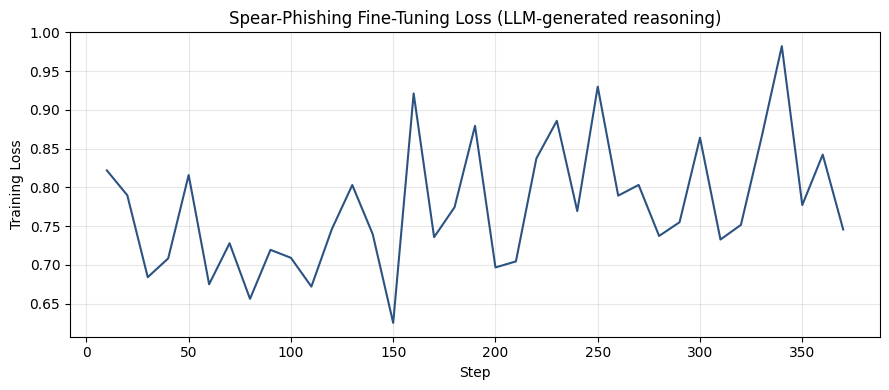

In [56]:
loss_history = trainer.state.log_history
losses = [(h["step"], h["loss"]) for h in loss_history if "loss" in h]
if losses:
    steps, vals = zip(*losses)
    plt.figure(figsize=(9, 4))
    plt.plot(steps, vals, linewidth=1.5, color="#2c5282")
    plt.xlabel("Step"); plt.ylabel("Training Loss")
    plt.title("Spear-Phishing Fine-Tuning Loss (LLM-generated reasoning)")
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig("training_loss.png", dpi=150)
    plt.show()

## 12. Evaluation After Fine-Tuning

In [57]:
print("=" * 60)
print("AFTER FINE-TUNING (LLM-generated reasoning)")
print("=" * 60)
ft_metrics, ft_results = evaluate_on_set(eval_data, name="fine-tuned")

AFTER FINE-TUNING (LLM-generated reasoning)


Evaluating (fine-tuned):   0%|          | 0/300 [00:00<?, ?it/s]


fine-tuned metrics:
  accuracy  : 0.9533
  precision : 1.0000
  recall    : 0.9067
  f1        : 0.9510
  fpr       : 0.0000
  tp        : 136
  fp        : 0
  fn        : 14
  tn        : 150


In [58]:
print("Fine-tuned sample outputs:\n")
for r in ft_results[:5]:
    correct = '✓' if r['is_correct'] else '✗'
    print(f"--- Truth: {r['label_str']}, Predicted: {r['predicted_str']}, {correct} ---")
    print(f"Output: {r['raw_output'][:400]}")
    print()

Fine-tuned sample outputs:

--- Truth: SAFE, Predicted: SAFE, ✓ ---
Output: The email is classified as SAFE because it contains a clear subject line indicating a specific date ("hpl noms. for dec. 29, 2000") and a clear reference to an attached file ("hplnl 229. xls"). This suggests that the email is a legitimate and organized communication from a trusted source, likely a company or organization. The use of a specific date and file name also implies a high level of profes

--- Truth: SAFE, Predicted: SAFE, ✓ ---
Output: This email is classified as SAFE because it appears to be a legitimate business communication from a company, as evidenced by the specific date and time of the event (6/16/99), the mention of a company name (Hungerford Grain Company), and the use of a formal greeting and signature ("daren :"). The tone is also professional and informative, with a clear request for approval. Verdict: SAFE.

--- Truth: SAFE, Predicted: SAFE, ✓ ---
Output: This email is classified as SAFE 

## 13. Compare Baseline vs. Fine-Tuned

In [59]:
rows = []
for metric in ["accuracy", "precision", "recall", "f1", "fpr"]:
    b = baseline_metrics[metric]; f = ft_metrics[metric]
    rows.append({"Metric": metric.upper(), "Baseline": f"{b:.4f}",
                 "Fine-tuned": f"{f:.4f}", "Delta": f"{f-b:+.4f}"})
print(pd.DataFrame(rows).to_string(index=False))
pd.DataFrame(rows).to_csv("phishing_before_after.csv", index=False)

   Metric Baseline Fine-tuned   Delta
 ACCURACY   0.5667     0.9533 +0.3867
PRECISION   0.5476     1.0000 +0.4524
   RECALL   0.7667     0.9067 +0.1400
       F1   0.6389     0.9510 +0.3122
      FPR   0.6333     0.0000 -0.6333


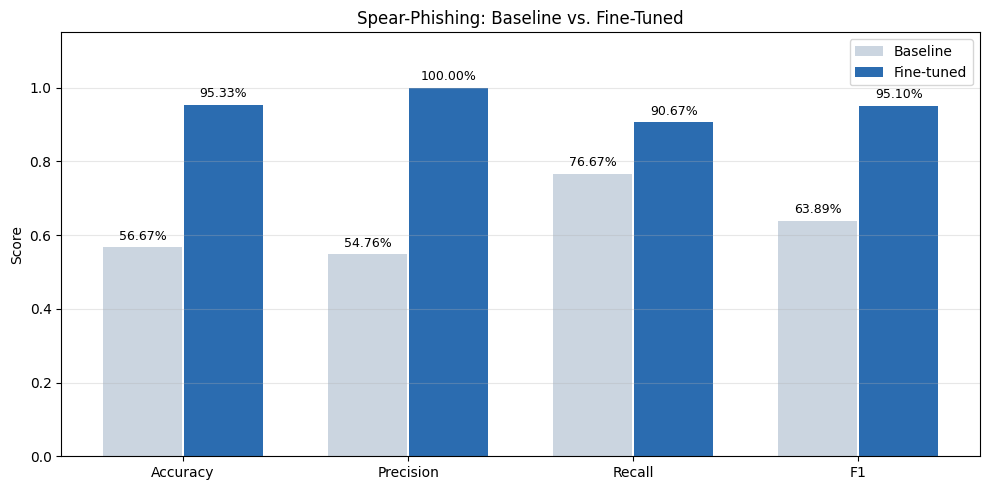

In [60]:
metric_names = ["Accuracy", "Precision", "Recall", "F1"]
base_vals = [baseline_metrics[m.lower()] for m in metric_names]
ft_vals   = [ft_metrics[m.lower()]       for m in metric_names]

x = np.arange(len(metric_names))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.18, base_vals, 0.35, label="Baseline",   color="#CBD5E0")
ax.bar(x + 0.18, ft_vals,   0.35, label="Fine-tuned", color="#2B6CB0")
ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("Spear-Phishing: Baseline vs. Fine-Tuned")
ax.legend(); ax.grid(axis='y', alpha=0.3)
for i, (b, f_) in enumerate(zip(base_vals, ft_vals)):
    ax.text(i - 0.18, b + 0.02, f"{b:.2%}", ha='center', fontsize=9)
    ax.text(i + 0.18, f_ + 0.02, f"{f_:.2%}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("before_after_comparison.png", dpi=150)
plt.show()

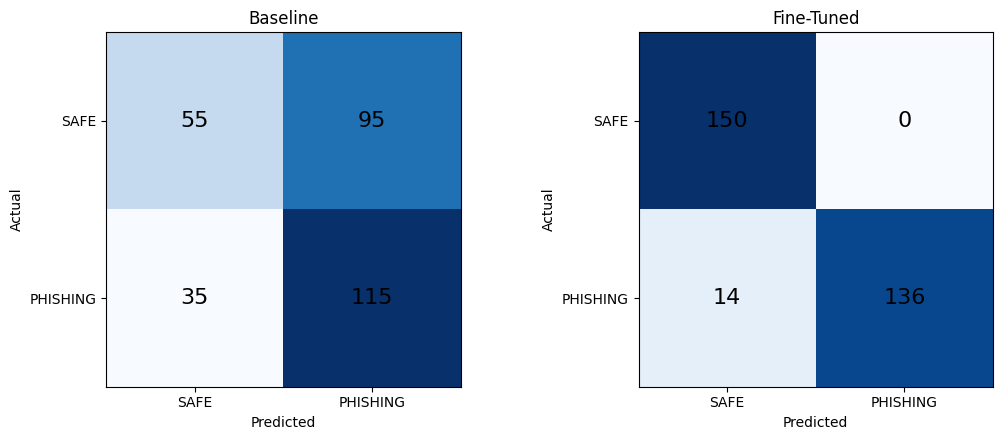

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
def plot_cm(ax, m, title):
    cm = np.array([[m["tn"],m["fp"]],[m["fn"],m["tp"]]])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i][j]), ha='center', va='center', fontsize=16)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["SAFE","PHISHING"]); ax.set_yticklabels(["SAFE","PHISHING"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
plot_cm(axes[0], baseline_metrics, "Baseline")
plot_cm(axes[1], ft_metrics, "Fine-Tuned")
plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=150); plt.show()

## 14. Qualitative Comparison

In [62]:
flipped = [(b,f) for b,f in zip(baseline_results, ft_results)
           if not b["is_correct"] and f["is_correct"]]
print(f"Cases corrected by fine-tuning: {len(flipped)}")
if flipped:
    b, f = flipped[0]
    print(f"\n=== Truth: {b['label_str']}, Source: {b['source']} ===")
    print(f"Email: {b['text'][:300]}...")
    print(f"\nBASELINE:  {b['raw_output'][:300]}")
    print(f"\nFINE-TUNED: {f['raw_output'][:300]}")

Cases corrected by fine-tuning: 120

=== Truth: SAFE, Source: enron ===
Email: Subject: hpl noms . for dec . 29 , 2000

( see attached file : hplnl 229 . xls )
- hplnl 229 . xls...

BASELINE:  Analysis:

* Suspicious URL: "hplnl 229. xls" does not appear to be a legitimate URL, as it lacks a protocol (http or https) and a domain name.
* Generic greeting: The email does not address the recipient by name.
* No clear indication of sender identity: The email does not provide a clear indicatio

FINE-TUNED: The email is classified as SAFE because it contains a clear subject line indicating a specific date ("hpl noms. for dec. 29, 2000") and a clear reference to an attached file ("hplnl 229. xls"). This suggests that the email is a legitimate and organized communication from a trusted source, likely a c


In [63]:
pd.DataFrame(baseline_results).to_csv("baseline_per_sample.csv", index=False)
pd.DataFrame(ft_results).to_csv("finetuned_per_sample.csv", index=False)
print("Saved per-sample results.")

Saved per-sample results.


## 15. Save Adapter and Export to GGUF

In [64]:
model.save_pretrained("llama-3.2-spearphishing-lora")
tokenizer.save_pretrained("llama-3.2-spearphishing-lora")
print("Saved LoRA adapter.")

Saved LoRA adapter.


In [65]:
print("Exporting to GGUF (Q4_K_M)... takes 10-15 minutes")
model.save_pretrained_gguf(
    "llama-3.2-spearphishing-gguf",
    tokenizer,
    quantization_method = "q4_k_m",
)
print("Done.")
!ls -lh llama-3.2-spearphishing-gguf/*.gguf

Exporting to GGUF (Q4_K_M)... takes 10-15 minutes
Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [06:59<00:00, 209.53s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [04:54<00:00, 147.35s/it]


Unsloth: Merge process complete. Saved to `/content/llama-3.2-spearphishing-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['llama-3.2-spearphishing-gguf_gguf/llama-3.2-3b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 

## 16. Ollama Modelfiles

In [66]:
SYSTEM_MSG = SYSTEM_PROMPT

# Baseline: pulls from Ollama registry (no GGUF needed)
modelfile_baseline = f'''FROM llama3.2:3b-instruct
SYSTEM """{SYSTEM_MSG}"""
PARAMETER temperature 0
PARAMETER num_ctx 4096
'''

# Fine-tuned: uses local GGUF
modelfile_finetuned = f'''FROM ./llama-3.2-spearphishing-gguf/unsloth.Q4_K_M.gguf
SYSTEM """{SYSTEM_MSG}"""
PARAMETER temperature 0
PARAMETER stop "<|start_header_id|>"
PARAMETER stop "<|end_header_id|>"
PARAMETER stop "<|eot_id|>"
PARAMETER num_ctx 4096
'''

with open("Modelfile.baseline", "w") as f:
    f.write(modelfile_baseline)
with open("Modelfile.finetuned", "w") as f:
    f.write(modelfile_finetuned)

print("Created Modelfile.baseline and Modelfile.finetuned")
print("\nLocal deployment:")
print("  ollama create phishing-baseline -f Modelfile.baseline")
print("  ollama create llama-spearphishing -f Modelfile.finetuned")

Created Modelfile.baseline and Modelfile.finetuned

Local deployment:
  ollama create phishing-baseline -f Modelfile.baseline
  ollama create llama-spearphishing -f Modelfile.finetuned


## 17. Save to Google Drive (optional)

In [69]:
import os
import shutil
from google.colab import files

# Define what to exclude to avoid zipping Google Drive or default Colab files
exclude_dirs = {'sample_data'}

# Create a directory to gather all the workspace files
backup_dir = 'full_workspace_backup'
os.makedirs(backup_dir, exist_ok=True)

print("Gathering files and folders...")
# Iterate through the current directory
for item in os.listdir('.'):
    # Skip excluded directories, the backup folder itself, and existing zip files to avoid recursion
    if item in exclude_dirs or item == backup_dir or item.endswith('.zip'):
        continue

    # Copy files and directories into the backup folder
    if os.path.isdir(item):
        shutil.copytree(item, os.path.join(backup_dir, item), dirs_exist_ok=True)
        print(f"Copied directory: {item}/")
    else:
        shutil.copy(item, backup_dir)
        print(f"Copied file: {item}")

# Zip the entire backup directory
zip_filename = 'llama-spearphishing-reasoning'
print(f"\nZipping everything into {zip_filename}.zip...")
shutil.make_archive(zip_filename, 'zip', backup_dir)
print(f"Created {zip_filename}.zip successfully!")

# Trigger the download to your local computer
files.download(f'{zip_filename}.zip')

# Optional: Copy to Google Drive
# shutil.copy(f'{zip_filename}.zip', '/content/drive/MyDrive/')

Gathering files and folders...
Copied directory: .config/
Copied file: training_loss.png
Copied directory: outputs_phishing/
Copied directory: llama-3.2-spearphishing-gguf/
Copied file: =0.16.0
Copied file: phishing_before_after.csv
Copied file: reasoning_cache.json
Copied file: baseline_per_sample.csv
Copied file: Modelfile.finetuned
Copied directory: llama-3.2-spearphishing-lora/
Copied file: Modelfile.baseline
Copied file: before_after_comparison.png
Copied directory: MachineLearningPhishing/
Copied directory: llama-3.2-spearphishing-gguf_gguf/
Copied file: finetuned_per_sample.csv
Copied file: eval_set.jsonl
Copied file: confusion_matrices.png
Copied directory: unsloth_compiled_cache/
Copied directory: huggingface_tokenizers_cache/

Zipping everything into llama-spearphishing-reasoning.zip...
Created llama-spearphishing-reasoning.zip successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>